# Extension-chord test: verify saved data for compact + B + D

Loads `data/extension_beams.npz` (written by `generate_data.py`) and plots the B+D combination to confirm the saved arrays are correct.

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

D = np.load("data/extension_beams.npz")
params = json.load(open("data/extension_params.json"))

combos = [str(c) for c in D["combos"]]
scale = params["beam_scale"]
l = D["l_arcmin"]
extent = [l[0], l[-1], l[0], l[-1]]

KEY = "B_D"
idx = combos.index(KEY)
print(f"combo {KEY!r} -> index {idx} of {len(combos)}")
print("weightings:", params["weightings"], "| beam_scale:", scale)
print("beam extent (arcmin):", params["beam_extent_arcmin"])

combo 'B_D' -> index 2 of 3
weightings: ['natural', 'briggs0', 'uniform'] | beam_scale: 10000
beam extent (arcmin): [-7.03125, 6.796875]


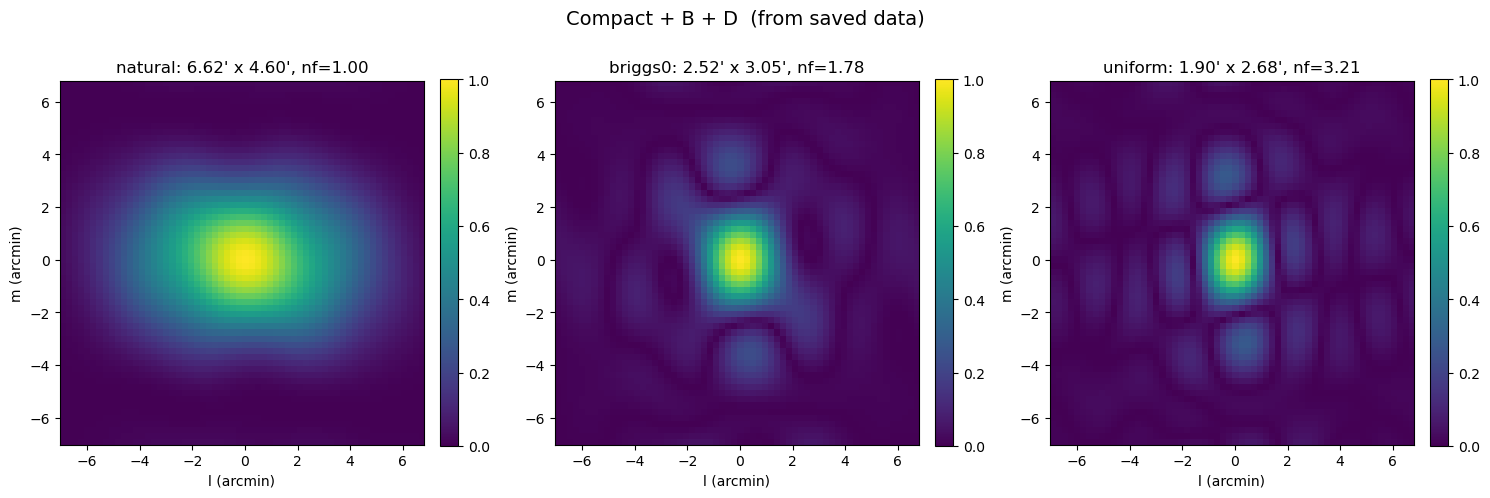

beam array shape: (60, 60) dtype: int16


In [9]:
# The three saved beams for B+D (int16 -> float via beam_scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, w in zip(axes, params["weightings"]):
    beam = D[f"beam_{w}"][idx].astype(float) / scale
    el, em, nf = D[f"eff_l_{w}"][idx], D[f"eff_m_{w}"][idx], D[f"noise_{w}"][idx]
    im = ax.imshow(beam, origin="lower", extent=extent, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{w}: {el:.2f}' x {em:.2f}', nf={nf:.2f}")
    ax.set_xlabel("l (arcmin)"); ax.set_ylabel("m (arcmin)")
    # ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Compact + B + D  (from saved data)", fontsize=14)
plt.tight_layout()
# plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.show()
print("beam array shape:", D["beam_uniform"][idx].shape, "dtype:", D["beam_uniform"].dtype)

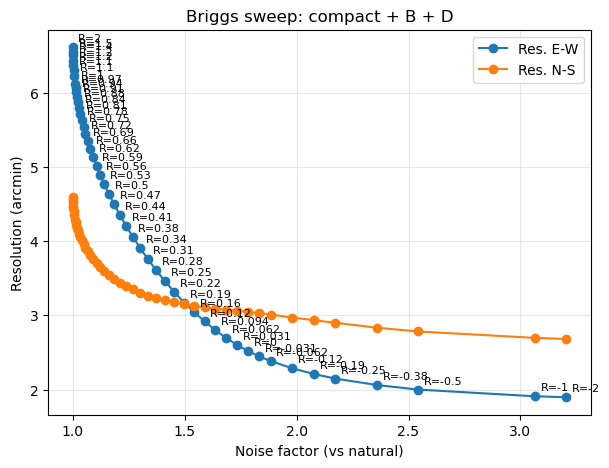

sweep has 49 robust points


In [10]:
# The saved Briggs sweep for B+D (4th dashboard panel)
r  = D[f"sweep_r_{KEY}"]
nf = D[f"sweep_nf_{KEY}"]
el = D[f"sweep_eff_l_{KEY}"]
em = D[f"sweep_eff_m_{KEY}"]
plt.figure(figsize=(7, 5))
plt.plot(nf, el, "o-", label="Res. E-W")
plt.plot(nf, em, "o-", label="Res. N-S")
for nf_i, el_i, r_i in zip(nf, el, r):
    plt.annotate(f"R={r_i:.2g}", (nf_i, el_i), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xlabel("Noise factor (vs natural)"); plt.ylabel("Resolution (arcmin)")
plt.title("Briggs sweep: compact + B + D"); plt.legend(); plt.grid(alpha=0.3)
plt.show()
print(f"sweep has {len(r)} robust points")